In [2]:
import pandas as pd
from pathlib import Path
import xarray as xr

ROOT_PATH = Path("/data01/FDS/muduchuru/Atmos/NEXGDDP_HYRAS_BC_CSV/")
ZARR_PATH = Path("/data01/FDS/muduchuru/Atmos/zarr_stores")
MODEL = 'ACCESS-CM2'
SCENARIO = 'ssp370'
mapper = 'rowcol_to_latlon.json'

In [3]:
def _smooth(df):
    df_monthly = df.resample('MS').mean()
    df_rolling = df_monthly.rolling(window=36).mean()
    return df_rolling

In [4]:
df_loc = pd.read_json(
    ROOT_PATH / MODEL / SCENARIO / mapper,
)

In [17]:
ROW = 573
COL = 124
LAT, LON = df_loc[f'{ROW},{COL}']

In [ ]:

HIST = 'historical'
FILE = f"{COL}/{MODEL}_{HIST}_19510101_20141231_C{COL}R{ROW}.csv"
df_hist = pd.read_csv(
    ROOT_PATH / MODEL / HIST / FILE,
    parse_dates=['time'],
    index_col='time',
)

FILE = f"{COL}/{MODEL}_{SCENARIO}_20150101_21001231_C{COL}R{ROW}.csv"
df_fut = pd.read_csv(
    ROOT_PATH / MODEL / SCENARIO / FILE,
    parse_dates=['time'],
    index_col='time',
)

df_full = pd.concat([df_hist, df_fut], axis=0)

FILE = f"NEX_GDDP_{MODEL}_{SCENARIO}_2015_2100.zarr"
ds = xr.open_dataset(ZARR_PATH / FILE)
df_raw = ds.sel(lat=LAT, lon=LON, method='nearest').to_dataframe()[['rsds']] * 86.4


/home/muduchuru/miniforge3/envs/sdba/lib/python3.10/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'radolan' loading failed:
module 'xarray' has no attribute 'register_datatree_accessor'
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
/home/muduchuru/miniforge3/envs/sdba/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home/muduchuru/miniforge3/envs/sdba/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'h5netcdf' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home/muduchuru/miniforge3/envs/sdba/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


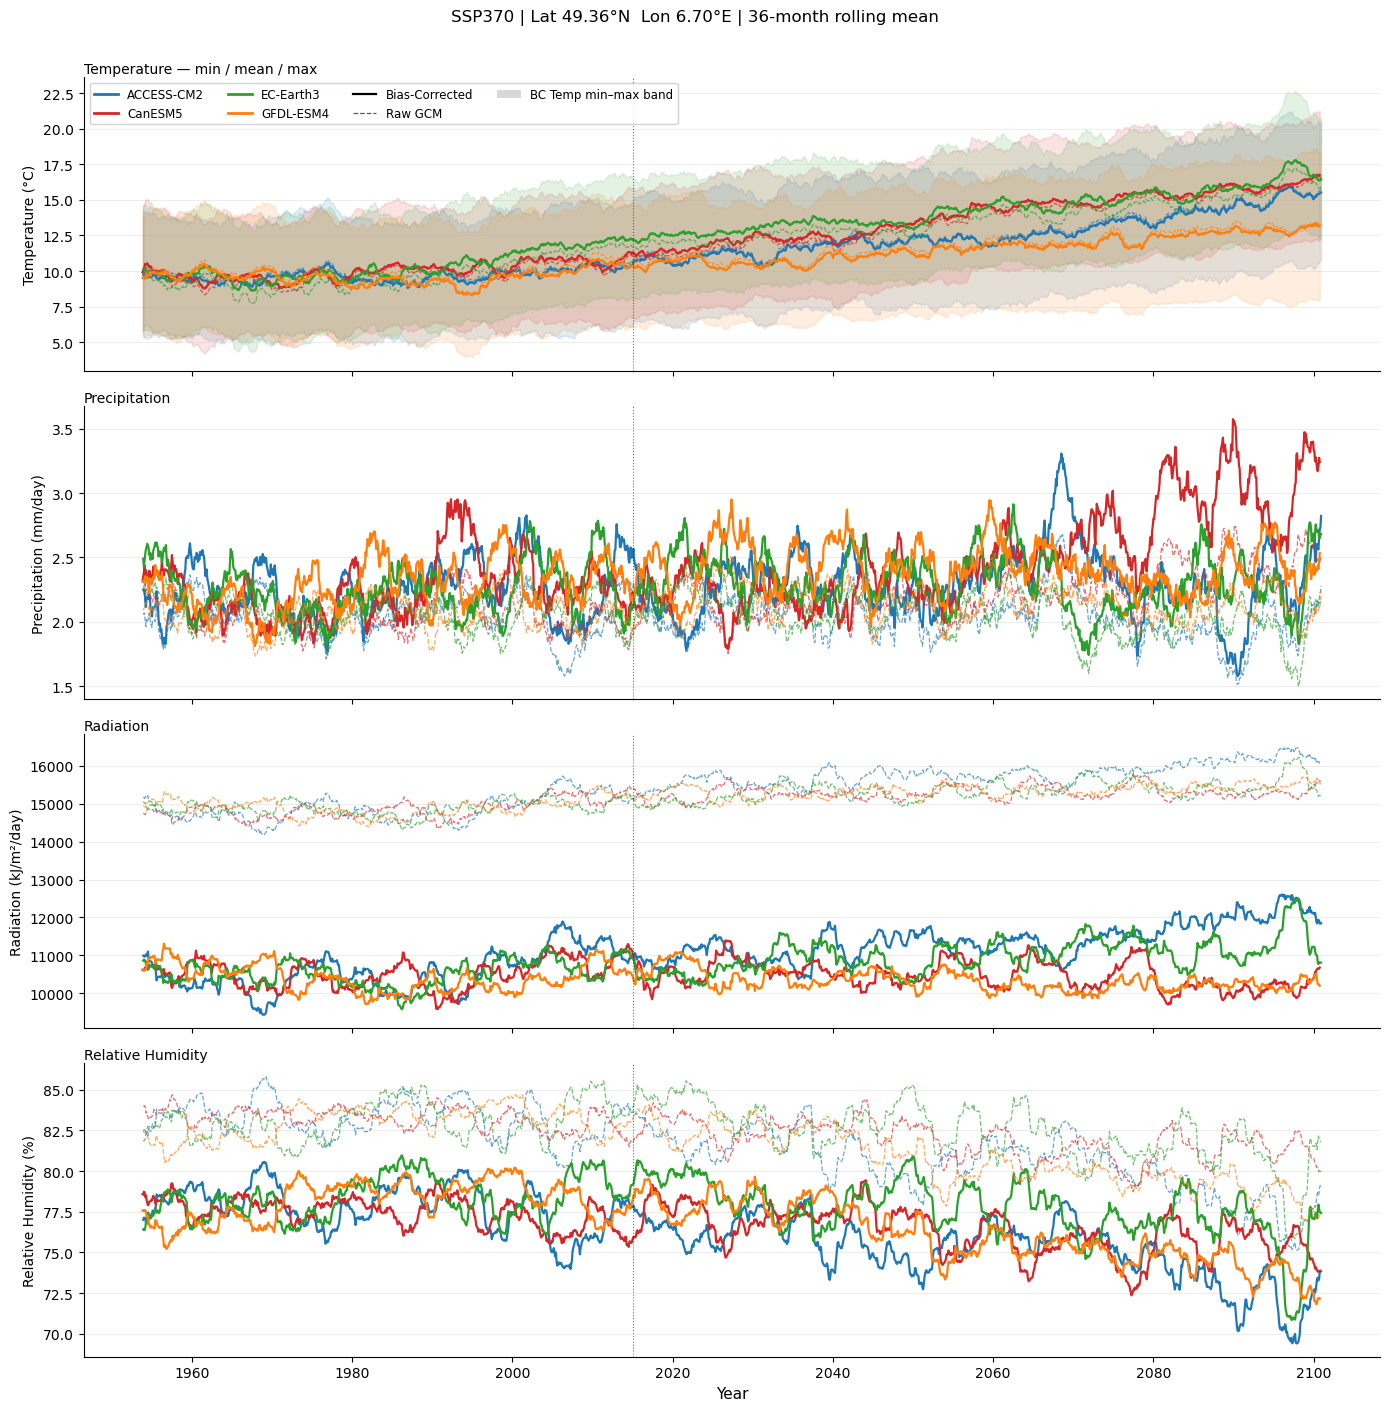

In [18]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

MODELS = ['ACCESS-CM2', 'CanESM5', 'EC-Earth3', 'GFDL-ESM4']#, 'MIROC6']
SCENARIO = 'ssp370'
MODEL_COLORS = {
    'ACCESS-CM2': '#1f77b4', 'CanESM5': '#d62728', 'EC-Earth3': '#2ca02c',
    'GFDL-ESM4':  '#ff7f0e',# 'MIROC6':  '#9467bd',
}
RAW_VARS = ['tas', 'tasmin', 'tasmax', 'pr', 'rsds', 'hurs']

def _xr_point(ds, lat, lon, variables):
    """Extract a point from a zarr Dataset into a DataFrame with DatetimeIndex.
    Handles both numpy datetime64 and cftime objects (noleap, 360_day, etc.)."""
    pt = ds.sel(lat=lat, lon=lon, method='nearest')
    times = pt.time.values
    try:
        index = pd.to_datetime(times)
    except TypeError:
        # cftime (e.g. DatetimeNoLeap) — extract date components directly
        index = pd.DatetimeIndex([pd.Timestamp(t.year, t.month, t.day) for t in times])
    return pd.DataFrame({v: pt[v].values for v in variables}, index=index)

# ── load all models ───────────────────────────────────────────────────────────
ts_data = {}
for model in MODELS:
    bc_h = pd.read_csv(
        ROOT_PATH / model / 'historical' / str(COL) /
        f"{model}_historical_19510101_20141231_C{COL}R{ROW}.csv",
        parse_dates=['time'], index_col='time')
    bc_f = pd.read_csv(
        ROOT_PATH / model / SCENARIO / str(COL) /
        f"{model}_{SCENARIO}_20150101_21001231_C{COL}R{ROW}.csv",
        parse_dates=['time'], index_col='time')
    bc = pd.concat([bc_h, bc_f])

    dsh = xr.open_dataset(ZARR_PATH / f"NEX_GDDP_{model}_historical_1951_2014.zarr")
    dsf = xr.open_dataset(ZARR_PATH / f"NEX_GDDP_{model}_{SCENARIO}_2015_2100.zarr")
    raw = pd.concat([_xr_point(dsh, LAT, LON, RAW_VARS),
                     _xr_point(dsf, LAT, LON, RAW_VARS)])
    for v in ['tas', 'tasmin', 'tasmax']: raw[v] -= 273.15   # K → °C
    raw['pr']   *= 86400   # kg/m²/s → mm/day
    raw['rsds'] *= 86.4    # W/m² → kJ/m²/day

    ts_data[model] = {'bc': bc, 'raw': raw}

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

PANELS = [
    dict(ax=axes[0],
         bc_cols=('TempMin', 'TempMean', 'TempMax'),
         raw_cols=('tasmin', 'tas', 'tasmax'),
         ylabel='Temperature (°C)', title='Temperature — min / mean / max'),
    dict(ax=axes[1],
         bc_cols=('Precipitation',), raw_cols=('pr',),
         ylabel='Precipitation (mm/day)', title='Precipitation'),
    dict(ax=axes[2],
         bc_cols=('Radiation',), raw_cols=('rsds',),
         ylabel='Radiation (kJ/m²/day)', title='Radiation'),
    dict(ax=axes[3],
         bc_cols=('RelHumCalc',), raw_cols=('hurs',),
         ylabel='Relative Humidity (%)', title='Relative Humidity'),
]

for model, color in MODEL_COLORS.items():
    bc_df  = ts_data[model]['bc']
    raw_df = ts_data[model]['raw']

    for p in PANELS:
        ax = p['ax']
        if len(p['bc_cols']) == 3:          # temperature: shaded band + mean line
            s_min  = _smooth(bc_df[p['bc_cols'][0]])
            s_mean = _smooth(bc_df[p['bc_cols'][1]])
            s_max  = _smooth(bc_df[p['bc_cols'][2]])
            s_raw  = _smooth(raw_df[p['raw_cols'][1]])
            ax.fill_between(s_min.index, s_min, s_max, color=color, alpha=0.13)
            ax.plot(s_mean.index, s_mean, color=color, lw=1.6, label=model)
            ax.plot(s_raw.index,  s_raw,  color=color, lw=0.9, ls='--', alpha=0.65)
        else:
            s_bc  = _smooth(bc_df[p['bc_cols'][0]])
            s_raw = _smooth(raw_df[p['raw_cols'][0]])
            ax.plot(s_bc.index,  s_bc,  color=color, lw=1.6, label=model)
            ax.plot(s_raw.index, s_raw, color=color, lw=0.9, ls='--', alpha=0.65)

for p in PANELS:
    ax = p['ax']
    ax.axvline(pd.Timestamp('2015-01-01'), color='k', lw=0.8, ls=':', alpha=0.55)
    ax.set_ylabel(p['ylabel'], fontsize=10)
    ax.set_title(p['title'], fontsize=10, loc='left', pad=3)
    ax.grid(axis='y', lw=0.4, alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Year', fontsize=11)

# ── shared legend ─────────────────────────────────────────────────────────────
model_handles = [mlines.Line2D([], [], color=MODEL_COLORS[m], lw=2, label=m) for m in MODELS]
style_handles = [
    mlines.Line2D([], [], color='k', lw=1.6, ls='-',  label='Bias-Corrected'),
    mlines.Line2D([], [], color='k', lw=0.9, ls='--', alpha=0.65, label='Raw GCM'),
    mpatches.Patch(facecolor='gray', alpha=0.3, label='BC Temp min–max band'),
]
axes[0].legend(handles=model_handles + style_handles,
               ncol=4, fontsize=8.5, loc='upper left', framealpha=0.88)

fig.suptitle(
    f'{SCENARIO.upper()} | Lat {LAT:.2f}°N  Lon {LON:.2f}°E | 36-month rolling mean',
    fontsize=12, y=1.005
)
plt.tight_layout()
plt.show()


In [1]:
LAT,LON

NameError: name 'LAT' is not defined

In [40]:
lon

49.25

## Climate change signal: (2070–2099) − (1980–2010)

**Metric — Signal-to-Noise Ratio (SNR):**
`SNR = Δmean / σ_hist`  where Δmean = future_mean − hist_mean and σ_hist = std of annual means over 1980–2010.

SNR is dimensionless and comparable across all variables regardless of units. SNR > 1 means the projected change exceeds the historical interannual variability — a climatologically meaningful threshold.

**Scatter:** x = raw GCM SNR, y = bias-corrected SNR. Points on the 1:1 line = BC preserves the change signal exactly. Spread = model uncertainty. Color = variable, marker = model.

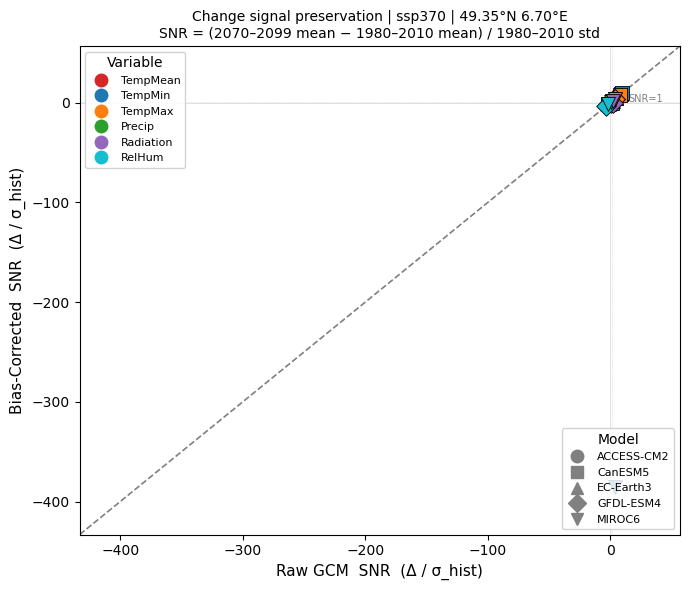

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import warnings
warnings.filterwarnings('ignore')

MODELS     = ['ACCESS-CM2', 'CanESM5', 'EC-Earth3', 'GFDL-ESM4', 'MIROC6']
SCENARIO   = 'ssp370'
HIST_SLICE = slice('1980', '2010')
FUT_SLICE  = slice('2070', '2099')

# bc_col → (raw_var, factor, offset, label)
VAR_MAP = {
    'TempMean':      ('tas',    1.0,   -273.15, 'TempMean'),
    'TempMin':       ('tasmin', 1.0,   -273.15, 'TempMin'),
    'TempMax':       ('tasmax', 1.0,   -273.15, 'TempMax'),
    'Precipitation': ('pr',     86400,  0.0,    'Precip'),
    'Radiation':     ('rsds',   86.4,   0.0,    'Radiation'),
    'RelHumCalc':    ('hurs',   1.0,    0.0,    'RelHum'),
}

VAR_COLORS = {
    'TempMean':      '#d62728',  # red
    'TempMin':       '#1f77b4',  # blue
    'TempMax':       '#ff7f0e',  # orange
    'Precipitation': '#2ca02c',  # green
    'Radiation':     '#9467bd',  # purple
    'RelHumCalc':    '#17becf',  # cyan
}
MARKERS = {'ACCESS-CM2': 'o', 'CanESM5': 's', 'EC-Earth3': '^', 'GFDL-ESM4': 'D', 'MIROC6': 'v'}

records = []

for model in MODELS:
    ds_h = xr.open_dataset(ZARR_PATH / f"NEX_GDDP_{model}_historical_1951_2014.zarr")
    ds_f = xr.open_dataset(ZARR_PATH / f"NEX_GDDP_{model}_{SCENARIO}_2015_2100.zarr")
    raw_h = ds_h.sel(lat=LAT, lon=LON, method='nearest')
    raw_f = ds_f.sel(lat=LAT, lon=LON, method='nearest')

    hist_csv = ROOT_PATH / model / 'historical' / str(COL) / \
               f"{model}_historical_19510101_20141231_C{COL}R{ROW}.csv"
    fut_csv  = ROOT_PATH / model / SCENARIO / str(COL) / \
               f"{model}_{SCENARIO}_20150101_21001231_C{COL}R{ROW}.csv"
    bc_h = pd.read_csv(hist_csv, parse_dates=['time'], index_col='time')
    bc_f = pd.read_csv(fut_csv,  parse_dates=['time'], index_col='time')

    for bc_col, (raw_var, factor, offset, label) in VAR_MAP.items():
        # raw annual means
        ra_h = (raw_h[raw_var] * factor + offset).resample(time='YE').mean()
        ra_f = (raw_f[raw_var] * factor + offset).resample(time='YE').mean()
        ra_hist = ra_h.sel(time=HIST_SLICE)
        raw_snr = ((ra_f.sel(time=FUT_SLICE).mean() - ra_hist.mean()) / ra_hist.std()).item()

        # BC annual means
        ba_h = bc_h[bc_col].resample('YE').mean()[HIST_SLICE]
        ba_f = bc_f[bc_col].resample('YE').mean()[FUT_SLICE]
        bc_snr = float((ba_f.mean() - ba_h.mean()) / ba_h.std())

        records.append(dict(model=model, var=bc_col, label=label,
                            raw_snr=raw_snr, bc_snr=bc_snr))

df_snr = pd.DataFrame(records)

# ── single scatter plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

lo = min(df_snr['raw_snr'].min(), df_snr['bc_snr'].min())
hi = max(df_snr['raw_snr'].max(), df_snr['bc_snr'].max())
pad = (hi - lo) * 0.12
lim = (lo - pad, hi + pad)

ax.plot(lim, lim, 'k--', lw=1.2, alpha=0.5, zorder=1)           # 1:1 line
ax.axhline(0, color='gray', lw=0.5, alpha=0.35)
ax.axvline(0, color='gray', lw=0.5, alpha=0.35)
ax.axhline(1, color='gray', lw=0.5, ls=':', alpha=0.4)           # SNR=1 guides
ax.axvline(1, color='gray', lw=0.5, ls=':', alpha=0.4)
ax.text(lim[1]-pad*0.3, 1.05, 'SNR=1', fontsize=7, color='gray', ha='right')

for _, r in df_snr.iterrows():
    ax.scatter(r['raw_snr'], r['bc_snr'],
               color=VAR_COLORS[r['var']], marker=MARKERS[r['model']],
               s=100, zorder=5, edgecolors='k', linewidths=0.6)

ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Raw GCM  SNR  (Δ / σ_hist)', fontsize=11)
ax.set_ylabel('Bias-Corrected  SNR  (Δ / σ_hist)', fontsize=11)
ax.set_title(
    f'Change signal preservation | {SCENARIO} | {LAT:.2f}°N {LON:.2f}°E\n'
    f'SNR = (2070–2099 mean − 1980–2010 mean) / 1980–2010 std',
    fontsize=10
)

var_handles = [
    mlines.Line2D([], [], color=VAR_COLORS[v], marker='o', linestyle='None',
                  ms=9, label=VAR_MAP[v][3])
    for v in VAR_MAP
]
model_handles = [
    mlines.Line2D([], [], color='gray', marker=m, linestyle='None',
                  ms=9, label=mod)
    for mod, m in MARKERS.items()
]
leg1 = ax.legend(handles=var_handles, title='Variable', fontsize=8,
                 loc='upper left', framealpha=0.85)
ax.add_artist(leg1)
ax.legend(handles=model_handles, title='Model', fontsize=8,
          loc='lower right', framealpha=0.85)

plt.tight_layout()
plt.show()
